In [1]:
import pandas as pd

import numpy as np

import pickle

import matplotlib.pyplot as plt

%matplotlib inline

import seaborn as sns

import sklearn

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import RandomizedSearchCV

import imblearn

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [12]:
data = pd.read_csv("../Datasets/loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


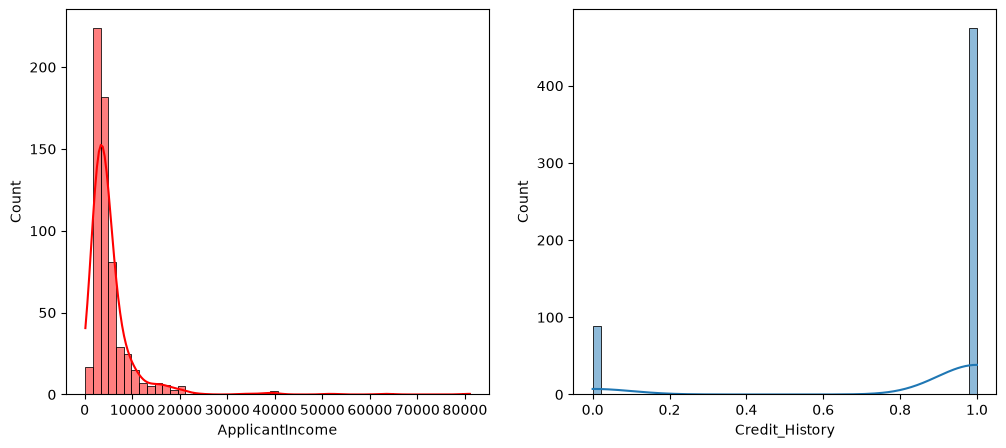

In [4]:
# plotting using histplot instead of distplot
plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.histplot(data['ApplicantIncome'], color='r', kde=True)

plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)

plt.show()

In [18]:
# 2. Encoding Categorical Variables
data = pd.read_csv("../Datasets/loan_prediction.csv")
data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})

# 3. Handling Missing Values
# Clean 'Dependents' column
data['Dependents'] = data['Dependents'].astype(str).str.replace('+', '')

cols_to_fill = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount']
for col in cols_to_fill:
    data[col] = data[col].fillna(data[col].mode()[0])

# 4. Converting Data Types to Integer
cols_to_convert = ['Gender', 'Married', 'Dependents', 'Self_Employed', 
                   'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

data[cols_to_convert] = data[cols_to_convert].fillna(0)

for col in cols_to_convert:
    data[col] = data[col].astype('int64')

# 5. Final Verification
print("\n--- Processing Complete ---")
print(data.head())


--- Processing Complete ---
    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       0        0           0          1              0   
1  LP001003       0        1           1          1              0   
2  LP001005       0        1           0          1              1   
3  LP001006       0        1           0          0              0   
4  LP001008       0        0           0          1              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                  0         120               360   
1             4583               1508         128               360   
2             3000                  0          66               360   
3             2583               2358         120               360   
4             6000                  0         141               360   

   Credit_History  Property_Area  Loan_Status  
0               1              2            1  
1               1          

In [30]:
data.columns

Index([' Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [53]:
# 2. Data Cleaning
# Remove missing values
from imblearn.over_sampling import SMOTE

# 3. Model Training
# 'Loan_Status' is the target column
X = data.drop(columns=['Loan_Status', ' Loan_ID'])
y = data['Loan_Status']

# Apply SMOTE to balance the dataset
smote = SMOTE()
x_bal, y_bal = smote.fit_resample(X, y)




print("Before OverSampling, counts of label '0': {}".format(sum(y == 0)))
print("After OverSampling, counts of label '0': {}".format(sum(y_bal == 0)))
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x_bal, y_bal, test_size=0.2, random_state=42)

#standardize the features
scaler = StandardScaler()   
X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

Before OverSampling, counts of label '0': 192
After OverSampling, counts of label '0': 422


In [44]:
def KNN(X_train,X_test,y_train,y_test):
    model = KNeighborsClassifier()
    model.fit(X_train,y_train)
    y_tr = model.predict(X_train)
    print("Model Accuracy:",int( accuracy_score(y_tr,y_train)*100), "%")
    yPred = model.predict(X_test)
    print("Test Accuracy:", int(accuracy_score(yPred,y_test)*100), "%")

In [54]:
print("Before standardize the features:")
KNN(X_train,X_test,y_train,y_test)
print("After standardize the features:")
KNN(X_train_st,X_test_st,y_train,y_test)

Before standardize the features:
Model Accuracy: 74 %
Test Accuracy: 68 %
After standardize the features:
Model Accuracy: 82 %
Test Accuracy: 72 %


In [55]:
print("from branch")

from branch
